In [1]:
import matplotlib.pyplot as plt
import numpy as np
import skrf as rf

rf.stylely()

In [2]:
freq = rf.Frequency(4, 10, 1001, "ghz")

from skrf_cqed.elements.coupled_lines import coupled_lines
from skrf_cqed.elements.tline_wrapper import DefinedBetaZ0

epsilon_r = 5.567
vph = rf.constants.c / np.sqrt(epsilon_r)

media = DefinedBetaZ0(frequency=freq, vph=vph, z0=50)


In [3]:
center_freq = 8e9

couple_deg = 20
couple_length = np.deg2rad(couple_deg) * vph / (2 * np.pi * center_freq)

coupler = coupled_lines(
    frequency=freq,
    length=couple_length,
    vph=vph,
    z0=50,
    name="Coupler",
    zetaC=0.7,
    zetaL=0.7,
)
d = 0.5

left_line = media.line_electrical_length(
    (1 - d) * 180 - couple_deg / 2, unit="deg", f0=center_freq, name="left_line"
)
right_line = media.line_electrical_length(
    d * 180 - couple_deg / 2, unit="deg", f0=center_freq, name="right_line"
)

openL = media.open(name="openL")
openR = media.open(name="openR")

gnd = rf.circuit.Circuit.Ground(freq, name="gnd")


In [4]:
portI = rf.circuit.Circuit.Port(freq, name="port0")
portO = rf.circuit.Circuit.Port(freq, name="port1")

cnx = [
    [(left_line, 0), (openL, 0)],
    [(right_line, 0), (openR, 0)],
    [(left_line, 1), (coupler, 0)],
    [(coupler, 2), (right_line, 1)],
    [(portI, 0), (coupler, 1)],
    [(coupler, 3), (portO, 0)],
]

circ = rf.circuit.Circuit(cnx, name="Resonator")


In [5]:
reduced_cnx = rf.circuit.reduce_circuit(cnx)
reduced_circ = rf.circuit.Circuit(reduced_cnx, name="Reduced Resonator")

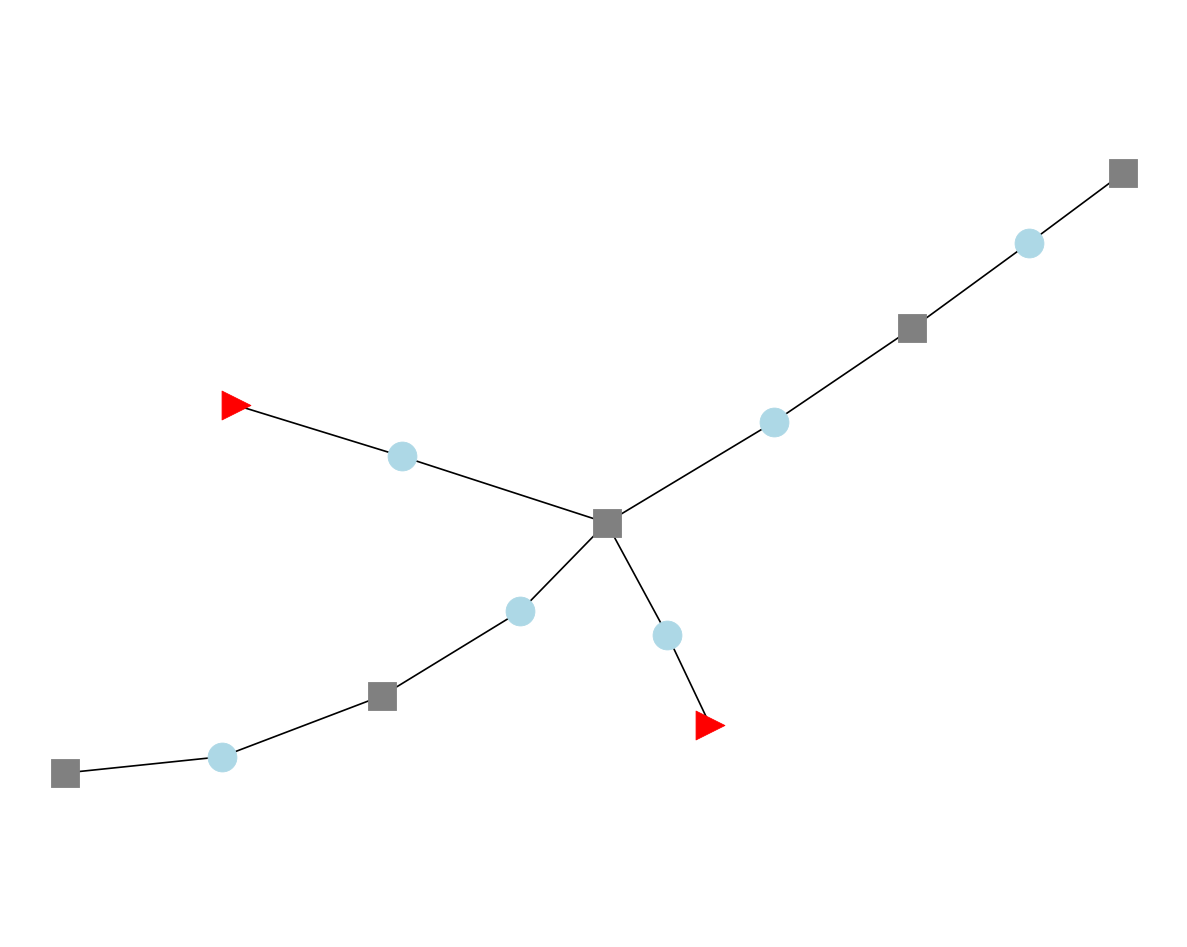

In [6]:
circ.plot_graph()

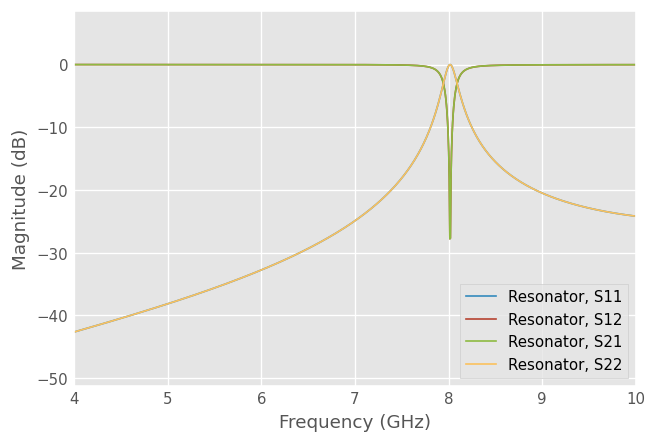

In [7]:
network = circ.network
network.plot_s_db()

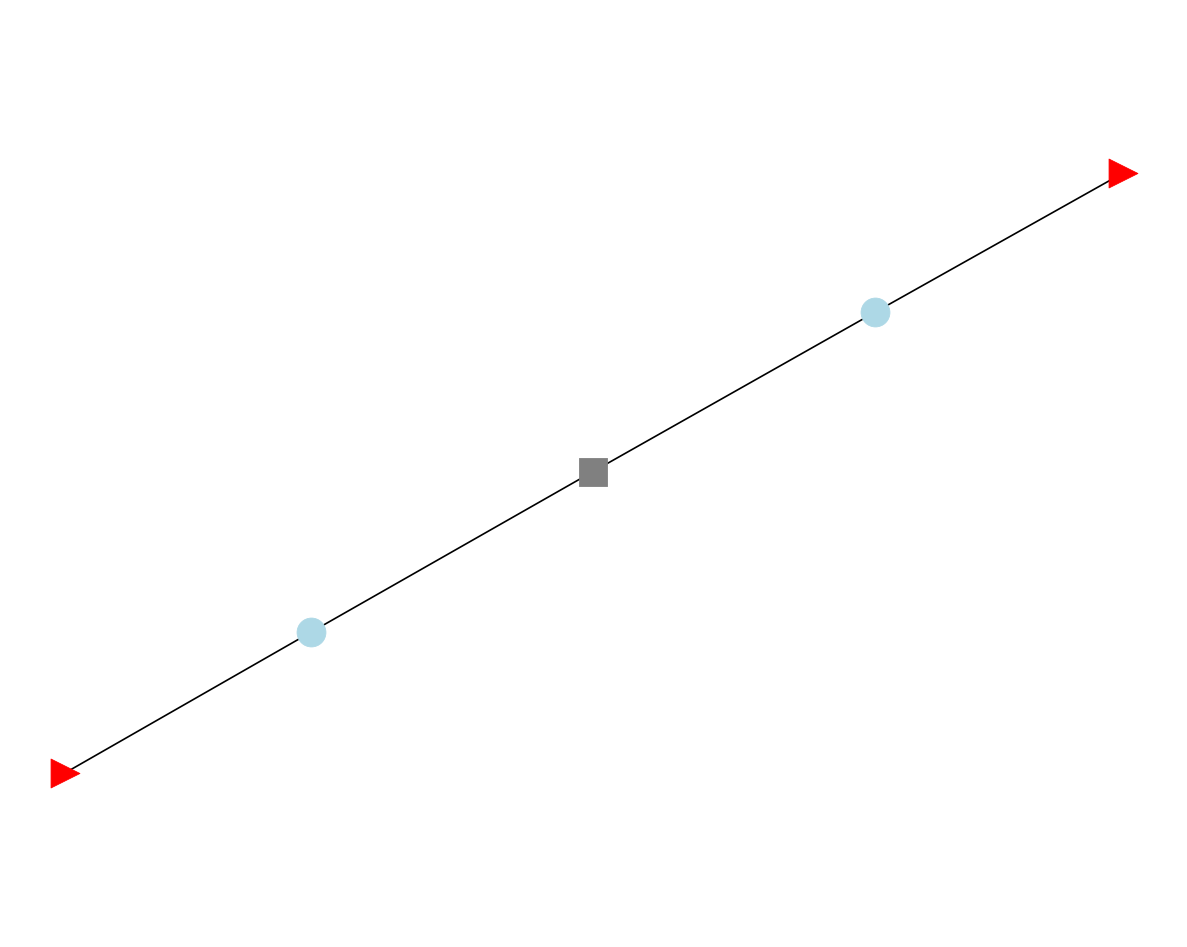

In [8]:
reduced_circ.plot_graph()

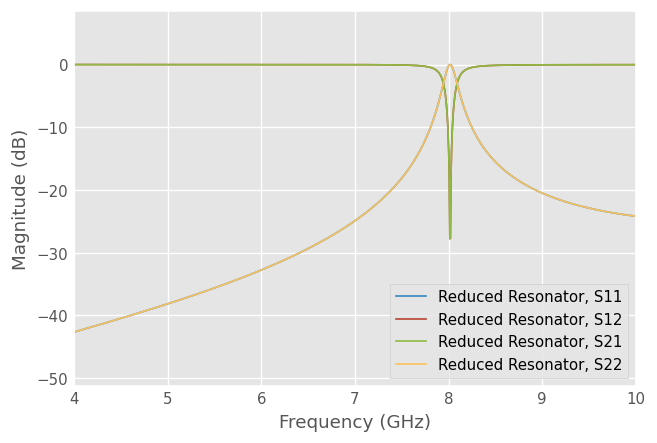

In [9]:
reduced_network = reduced_circ.network
reduced_network.plot_s_db()